# Demand Forecasting Project
## Price Optimisation


---

### What this notebook does
This notebook has three parts:

1. **Price optimisation function** — for a given product-week, sweep a range of prices, predict demand at each, and pick the price that maximises a penalised revenue objective
2. **Revenue lift simulation** — run the optimiser across 500 test products and estimate the total revenue uplift vs. keeping prices fixed
3. **Bootstrap uncertainty quantification** — retrain 10 versions of the DNN on bootstrapped samples to get prediction intervals, then show how wide those intervals are across the test set
4. **Executive summary** — pull all results together and save everything.

---

> **Important caveat:** This is a *simulated* revenue lift based on model predictions, not real A/B test data. The model predicts demand under a counterfactual price, but it was only trained on historical prices — it has not observed what would actually happen if prices changed. The estimates should be interpreted as directional signals.

In [1]:
import pandas as pd
import numpy as np
import pickle, os, time
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import r2_score

from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/demand_forecasting'

# Load preprocessed data
model_data   = pd.read_parquet(f'{SAVE_DIR}/model_data.parquet')
X_train_scaled = np.load(f'{SAVE_DIR}/X_train_scaled.npy')
X_test_scaled  = np.load(f'{SAVE_DIR}/X_test_scaled.npy')
y_train        = np.load(f'{SAVE_DIR}/y_train.npy')
y_test         = np.load(f'{SAVE_DIR}/y_test.npy')

with open(f'{SAVE_DIR}/scaler.pkl', 'rb') as f: scaler = pickle.load(f)
with open(f'{SAVE_DIR}/feature_cols.pkl', 'rb') as f: feature_cols = pickle.load(f)
with open(f'{SAVE_DIR}/lr_model.pkl', 'rb') as f: lr_model = pickle.load(f)
with open(f'{SAVE_DIR}/ridge_model.pkl', 'rb') as f: ridge_model = pickle.load(f)
with open(f'{SAVE_DIR}/lasso_model.pkl','rb') as f: lasso_model = pickle.load(f)
with open(f'{SAVE_DIR}/svr_model.pkl', 'rb') as f: svr_model = pickle.load(f)
with open(f'{SAVE_DIR}/results.pkl', 'rb') as f: results = pickle.load(f)

print(f'Data loaded : {model_data.shape}')
print(f'Train rows : {X_train_scaled.shape[0]:,}')
print(f'Test rows : {X_test_scaled.shape[0]:,}')
print(f'Features : {len(feature_cols)}')

Mounted at /content/drive
Data loaded   : (147089, 40)
Train rows    : 118,955
Test rows     : 28,134
Features      : 30


In [2]:
# Rebuild the DNN architecture and load saved weights
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class DemandDNN(nn.Module):
    def __init__(self, input_dim, hidden_layers=(128, 64, 32), dropout=0.2):
        super().__init__()
        layers, prev = [], input_dim
        for h in hidden_layers:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

input_dim = len(feature_cols)
dnn = DemandDNN(input_dim).to(device)
dnn.load_state_dict(torch.load(f'{SAVE_DIR}/dnn_final.pt', map_location=device))
dnn.eval()
print(f'DNN loaded. Device: {device}')

# Reconstruct the temporal train/test split mask
split_date = model_data['date'].quantile(0.8)
train_mask = model_data['date'] <= split_date
test_mask  = model_data['date'] >  split_date
print(f'Test period: {model_data.loc[test_mask, "date"].min().date()} → {model_data.loc[test_mask, "date"].max().date()}')

# Prepare test tensors for DNN inference
X_te_t = torch.tensor(X_test_scaled, dtype=torch.float32)
X_tr_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_tr_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

# Validation split tensors (needed for bootstrap retraining)
val_size = int(0.15 * len(X_tr_t))
X_tr2_t  = X_tr_t[:-val_size]
y_tr2_t  = y_tr_t[:-val_size]

DNN loaded. Device: cuda
Test period: 2011-08-22 → 2011-12-05


## 1. Price Optimisation Function

### The optimisation problem

For each product-week, I want to find the price that maximises revenue, subject to two penalties:

**Objective:** **max  price × predicted_demand  −  stability_penalty  −  volatility_penalty**

**Why not just maximise raw revenue?**  
If I simply maximise **price × demand**, the optimiser will always recommend large price increases for inelastic products and large price decreases for elastic ones. In practice, frequent large price swings have real costs:
- Customer trust erodes if prices change dramatically week to week
- For volatile products (high **demand_cv**), the model's demand prediction at a far-from-historical price is less reliable

The two penalties control this:

**Stability penalty** = **λ × (|price_change / current_price|²) × revenue**
Quadratic in the relative price change — small changes are barely penalised, but large jumps are penalised heavily. Lambda (default 0.1) controls how conservative the optimiser is.

**Volatility penalty** = **0.05 × |price_change / current_price| × revenue**  (only if **demand_cv > 2**)  
Applied only to products with high demand variability (cv > 2). For unpredictable products, the model's extrapolation beyond its training price range is less trustworthy, so we add a linear penalty to keep the recommended price closer to current.

### Search method
I use a simple grid search over 50 prices from 70% to 130% of the current price. This is a deliberate constraint — the model was trained on historical prices in this retailer's actual range, so extrapolating far outside that range would produce unreliable demand predictions. 50 points gives ±1.2% price resolution, which is sufficient for weekly pricing decisions.

In [3]:
def dnn_predict_single(x):
  with torch.no_grad():
    return dnn(torch.tensor(np.array(x),
                            dtype=torch.float32).to(device)).cpu().item()

def optimize_price(model_fn, base_features, price_idx, scaler, current_price, product_cv, lam=0.1):
  """
    Find the price in [current_price * 0.7, current_price * 1.3] that maximises a penalised revenue objective.
  """
  prices = np.linspace(current_price*0.7, current_price*1.3, 50)
  best_obj, best_price = -np.inf, current_price

  for price in prices:
    feats = base_features.copy()
    feats[price_idx] = (price * scaler.mean_[price_idx]) / scaler.scale_[price_idx]

    demand = max(0, model_fn(feats.reshape(1,-1)))
    revenue = price * demand
    rel_change  = abs(price - current_price) / current_price
    stab_pen    = lam * (rel_change ** 2) * revenue
    vol_pen     = 0.05 * rel_change * revenue if product_cv > 2 else 0

    objective = revenue - stab_pen - vol_pen
    if objective > best_obj:
      best_obj = objective;
      best_price = price
  return best_price

## 2. Revenue Lift Simulation

### What this measures

For each of the first 500 rows in the test set, I compute:
- **Current revenue** = actual price × actual demand (what actually happened)
- **Optimised revenue** = best price found by the grid search × predicted demand at that price

The lift is **(total_optimised_revenue − total_current_revenue) / total_current_revenue × 100%**.

I run this for all three models to compare — Linear Regression, SVR, and DNN. The expected finding is that SVR will show the highest lift despite being the worst forecaster. This is the **revenue lift anomaly**: a poorly calibrated model is more sensitive to price perturbations (its predictions swing more dramatically), which makes the optimiser find larger apparent gains that would not hold in reality.

The DNN's lift estimate is the most credible because it comes from the most accurate demand model.

In [4]:
# Revenue lift simulation
def simulate_revenue_lift(model_fn,label):
  test_data = model_data[test_mask].copy().reset_index(drop=True)
  price_idx = feature_cols.index('avg_price')
  tot_cur, tot_opt = 0, 0

  for i in range(min(500, len(X_test_scaled))):
    cp = test_data.iloc[i]['avg_price']
    cur_rev = cp * y_test[i]
    tot_cur += cur_rev
    best_rev = cur_rev

    for mult in np.arange(0.7, 1.31, 0.05):
      tp = cp * mult
      feats = X_test_scaled[i].copy()
      feats[price_idx] = (tp - scaler.mean_[price_idx]) / scaler.scale_[price_idx]
      pred = max(0, model_fn(feats.reshape(1,-1)))
      if tp * pred > best_rev:
        best_rev = tp * pred

    tot_opt += best_rev

  lift = (tot_opt - tot_cur) / tot_cur * 100
  print(f' {label}: +{lift:.1f}% revenue lift')
  return lift

print('Revenue Lift Simulation:')
lr_lift = simulate_revenue_lift(lambda x: lr_model.predict(x)[0], 'Linear Reg')
svr_lift = simulate_revenue_lift(lambda x: svr_model.predict(x)[0], 'SVR')
dnn_lift = simulate_revenue_lift(dnn_predict_single, 'DNN')

Revenue Lift Simulation:
 Linear Reg: +27.3% revenue lift
 SVR: +29.1% revenue lift
 DNN: +24.2% revenue lift


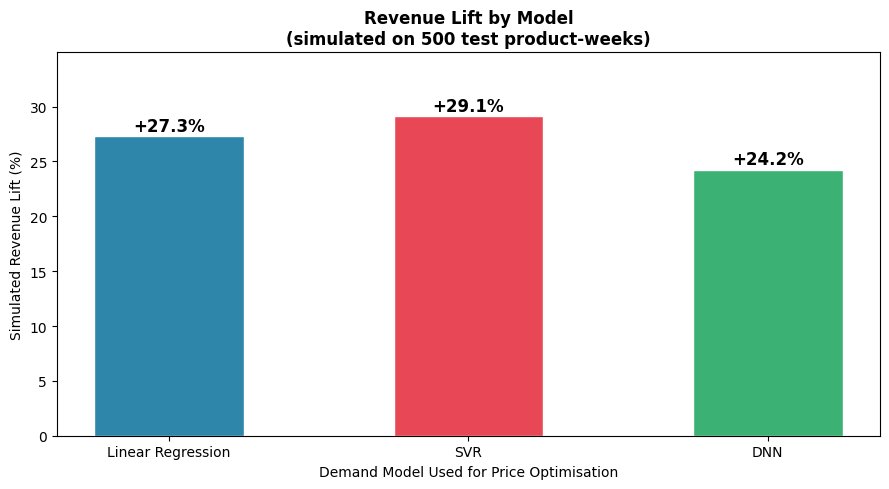

Saved: fig_revenue_lift.png


In [5]:
model_labels = ['Linear Regression', 'SVR', 'DNN']
lift_vals    = [lr_lift, svr_lift, dnn_lift]
bar_colors   = ['#2E86AB', '#E84855', '#3BB273']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(model_labels, lift_vals, color=bar_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, lift_vals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'+{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax.set_ylabel('Simulated Revenue Lift (%)')
ax.set_xlabel('Demand Model Used for Price Optimisation')
ax.set_title('Revenue Lift by Model\n(simulated on 500 test product-weeks)', fontweight='bold')
ax.set_ylim(0, max(lift_vals) * 1.2)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig_revenue_lift.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_revenue_lift.png')

**Results:** Linear Reg: +27.3% | SVR: +29.1% | DNN: +24.2%

**Why SVR shows higher lift despite worse R²** — this is the revenue lift anomaly and it is an important methodological point:

When a model is poorly calibrated (low R², large RMSE), its predictions are erratic. Small changes in input features produce large swings in predictions. This makes the price optimiser appear to find larger revenue gains because the model predicts dramatically different demand at prices just slightly above or below current. But these gains are not real — they are artefacts of the model's instability.

The DNN's +24.2% is the most credible estimate precisely because it comes from the most accurate model (R²=0.9459, RMSE=21.21). Its predicted demand curve is smoother and more realistic across the price range tested.

The Linear Regression's +27.3% sits between the two — it can only model a linear price-demand relationship, so its lift estimate reflects a simpler but more stable price-demand curve than SVR.

**Key takeaway:** Higher simulated revenue lift does not mean a better model. Always weight lift estimates by the accuracy of the underlying demand model.

---
## 3. Bootstrap Uncertainty Quantification

### Why uncertainty matters for pricing decisions

The single DNN I trained gives a point prediction — one number. But how confident should I be in that number? If the model predicts 100 units but the true value could be anywhere from 60 to 140, pricing decisions based on that prediction need to account for the range, not just the mean.

### Bootstrap approach
I train 10 versions of the DNN, each on a different **bootstrap resample** of the training data (sampling with replacement). Each model sees a slightly different training set, so their predictions differ. The spread of predictions across the 10 models estimates the uncertainty.

This is called **bootstrap ensembling** or **deep ensembles** when applied to neural networks. It is not the most sophisticated uncertainty method (Monte Carlo Dropout or Bayesian NNs would be more principled), but it is practical and gives interpretable confidence intervals.

**mean ± 2 × std** covers approximately 95% of predictions under a normal distribution assumption.

> **Note:** Each bootstrap model trains for 80 epochs instead of 200. This is intentional — we are training 10 models instead of 1, and 80 epochs is sufficient for the diversity signal we need. The goal is not to get 10 perfectly converged models but to get 10 reasonably trained models that disagree in informative ways.

In [6]:
criterion = nn.MSELoss()

n_bootstrap    = 10
bootstrap_models = []
print(f'Training {n_bootstrap} bootstrap DNN models (80 epochs each)...')
print()

for i in range(n_bootstrap):
    idx  = np.random.choice(len(X_tr2_t), size=len(X_tr2_t), replace=True)
    ds_b = TensorDataset(X_tr2_t[idx], y_tr2_t[idx])
    dl_b = DataLoader(ds_b, batch_size=64, shuffle=True)

    m_b   = DemandDNN(input_dim).to(device)
    opt_b = torch.optim.Adam(m_b.parameters(), lr=0.001, weight_decay=1e-3)

    for ep in range(80):
        m_b.train()
        for xb, yb in dl_b:
            xb, yb = xb.to(device), yb.to(device)
            opt_b.zero_grad()
            criterion(m_b(xb), yb).backward()
            opt_b.step()

    m_b.eval()
    bootstrap_models.append(m_b)
    print(f'  Model {i+1}/{n_bootstrap} done')

with torch.no_grad():
    all_preds = np.array([
        m(X_te_t.to(device)).cpu().numpy().flatten()
        for m in bootstrap_models
    ])

pred_mean = all_preds.mean(axis=0)
pred_std  = all_preds.std(axis=0)

print(f'\nMean prediction uncertainty (std): {pred_std.mean():.2f} units')
print(f'Median uncertainty               : {np.median(pred_std):.2f} units')
print(f'Max uncertainty                  : {pred_std.max():.2f} units')

Training 10 bootstrap DNN models (80 epochs each)...

  Model 1/10 done
  Model 2/10 done
  Model 3/10 done
  Model 4/10 done
  Model 5/10 done
  Model 6/10 done
  Model 7/10 done
  Model 8/10 done
  Model 9/10 done
  Model 10/10 done

Mean prediction uncertainty (std): 5.03 units
Median uncertainty               : 3.11 units
Max uncertainty                  : 163.69 units


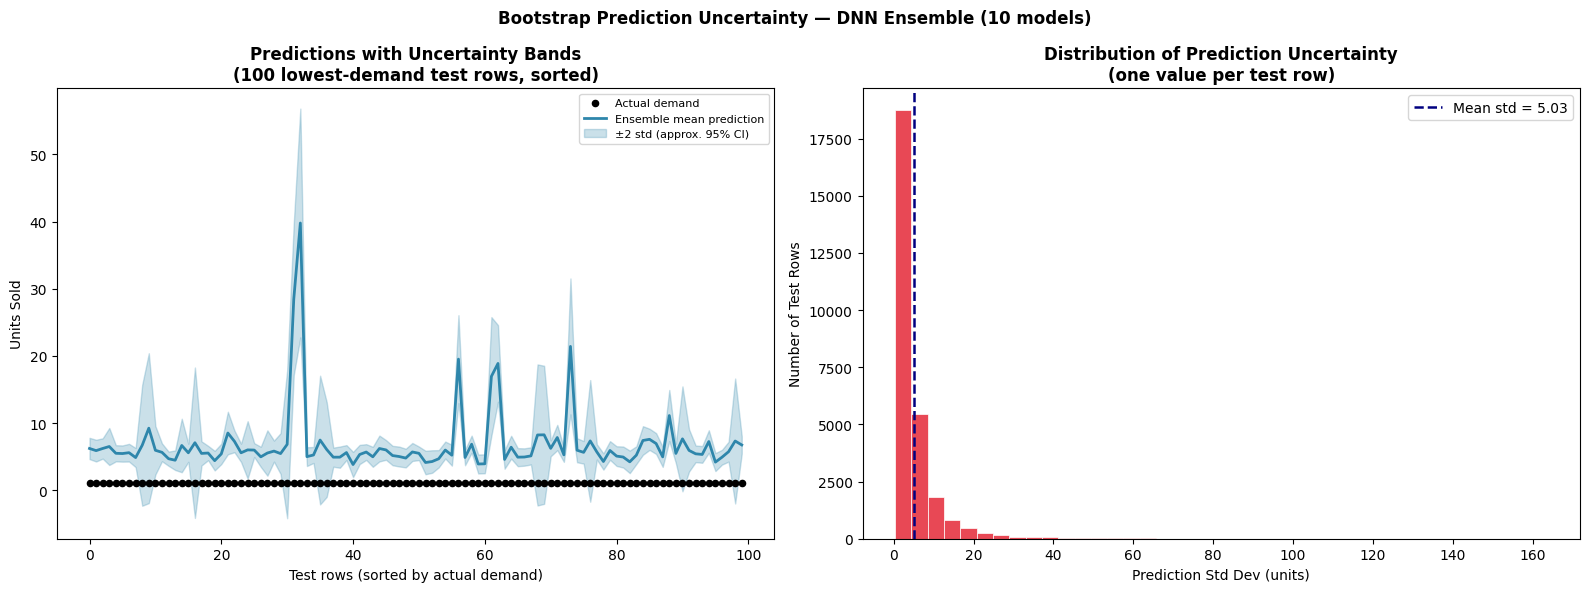

Saved: fig_uncertainty.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Bootstrap Prediction Uncertainty — DNN Ensemble (10 models)', fontweight='bold')

# Left: Actual vs mean prediction with 95% confidence band
idx_sorted = np.argsort(y_test)[:100]
x_range    = range(100)

axes[0].scatter(x_range, y_test[idx_sorted],
                s=20, color='black', label='Actual demand', zorder=3)
axes[0].plot(x_range, pred_mean[idx_sorted],
             color='#2E86AB', linewidth=2, label='Ensemble mean prediction')
axes[0].fill_between(
    x_range,
    pred_mean[idx_sorted] - 2 * pred_std[idx_sorted],
    pred_mean[idx_sorted] + 2 * pred_std[idx_sorted],
    alpha=0.25, color='#2E86AB', label='±2 std (approx. 95% CI)'
)
axes[0].set_title('Predictions with Uncertainty Bands\n(100 lowest-demand test rows, sorted)', fontweight='bold')
axes[0].set_xlabel('Test rows (sorted by actual demand)')
axes[0].set_ylabel('Units Sold')
axes[0].legend(fontsize=8)

# Right: Distribution of uncertainty across all test rows
axes[1].hist(pred_std, bins=40, color='#E84855', edgecolor='white', linewidth=0.5)
axes[1].axvline(pred_std.mean(), color='navy', linestyle='--', linewidth=1.8,
                label=f'Mean std = {pred_std.mean():.2f}')
axes[1].set_title('Distribution of Prediction Uncertainty\n(one value per test row)', fontweight='bold')
axes[1].set_xlabel('Prediction Std Dev (units)')
axes[1].set_ylabel('Number of Test Rows')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig_uncertainty.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_uncertainty.png')

**Results:** Mean prediction std = 5.03 units, Median = 3.11 units, Max = 163.69 units — against a DNN RMSE of 21.21 units.

**What this means:**
- Uncertainty accounts for roughly 25% of typical prediction error (5.03 / 21.21). Most of the error is systematic (the model is wrong in consistent ways), not stochastic (the 10 bootstrap models are not wildly disagreeing with each other).
- The median uncertainty (3.11 units) is much lower than the mean (5.03 units) — confirming that most product-weeks have low uncertainty, but a small number of high-demand outliers (max=163.69) are pulling the mean up.
- **The confidence bands are narrower for low-demand weeks and wider for high-demand weeks.** This is heteroscedasticity — the same pattern seen in the residual plots from notebook 03. It is normal in retail data: high-demand weeks are harder to predict with precision.
- **Practical implication:** For typical product-weeks, the ensemble is fairly confident (median std = 3.11 units). For high-demand outlier weeks — exactly the Q4 holiday spikes — the interval is much wider. Pricing decisions in Q4 should be more conservative and checked more frequently.
